In [1]:
import numpy as np
import cloudViewer as cv3d
import os
import sys

# monkey patches visualization and provides helpers to load geometries
sys.path.append('..')
import cloudViewer_tutorial as cv3dtut
# change to True if you want to interact with the visualization windows
cv3dtut.interactive = not "CI" in os.environ

Using external CloudViewer-ML in /root/CloudViewer-ML


# Half Edge Mesh

This tutorial outlines the following:
1. How to use `mesh_show_back_face` to render the backface of a mesh.
2. How to use `geometry.AxisAlignedBoundingBox` to crop a mesh. 
3. How to use `utility.Vector3dVector` to colorize boundary vertices of a mesh to red. 

## Render the backface of a Mesh

In order to render the backface of a mesh `visualization.draw_geometries()` is called with the flag `mesh_show_back_face` set to `True`.

[CloudViewer WARNING] GLFW Error: X11: The DISPLAY environment variable is missing
[CloudViewer WARNING] GLFW initialized for headless rendering.


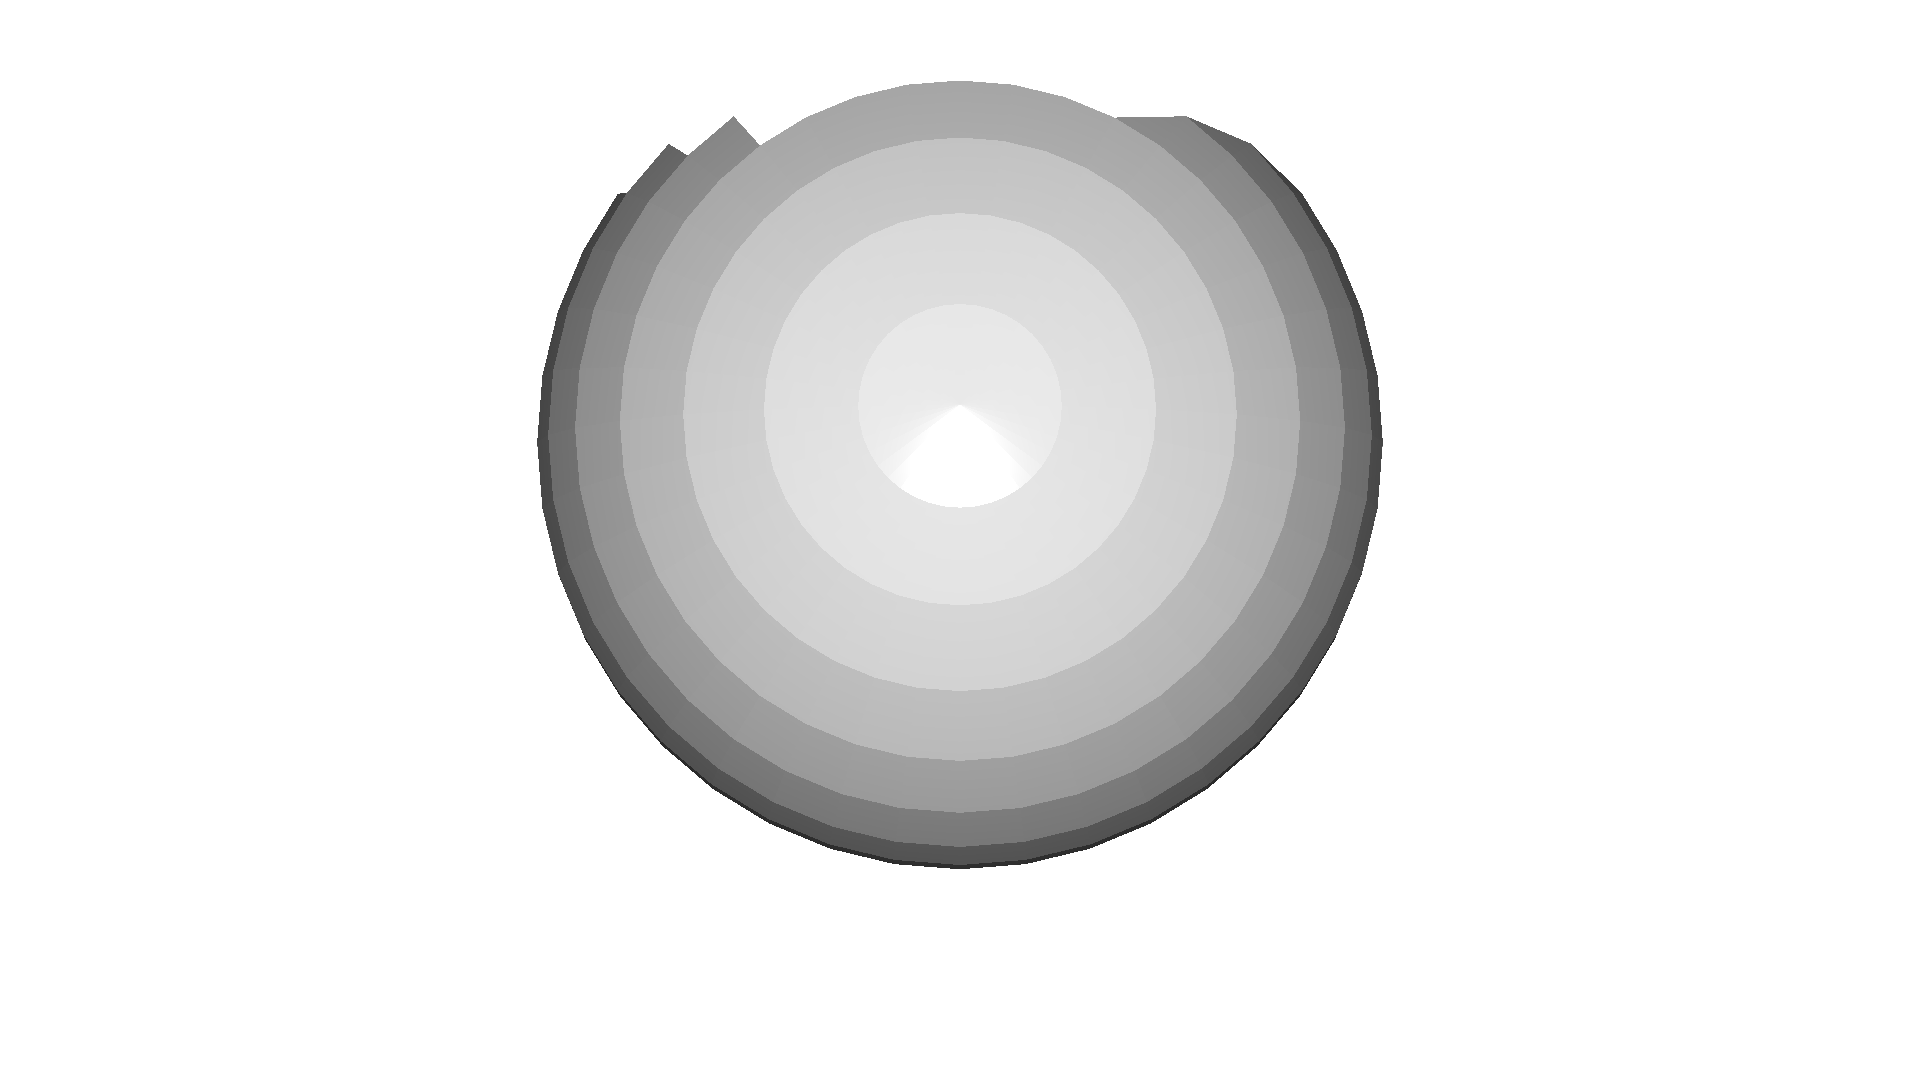

In [2]:
# Initialize a HalfEdgeTriangleMesh from TriangleMesh
mesh = cv3d.geometry.ccMesh.create_sphere()
bbox = cv3d.geometry.ccBBox()
bbox.set_min_bound([-1, -1, -1])
bbox.set_max_bound([1, 0.6, 1])
bbox.set_validity(True)
mesh = mesh.crop(bbox)
het_mesh = cv3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(mesh)
cv3d.visualization.draw_geometries([het_mesh], mesh_show_back_face=True)

## Cropping a Mesh

`geometry.AxisAlignedBoundingBox` is used to create an axis aligned box. The parameters `min_bound` and `max_bound` take an array of cartesian coordinates (x,y,z) and define the size of the bounding box. The bounds are set such that the y-axis of the sphere mesh is cut by a call to `crop`.

[CloudViewer WARNING] GLFW initialized for headless rendering.


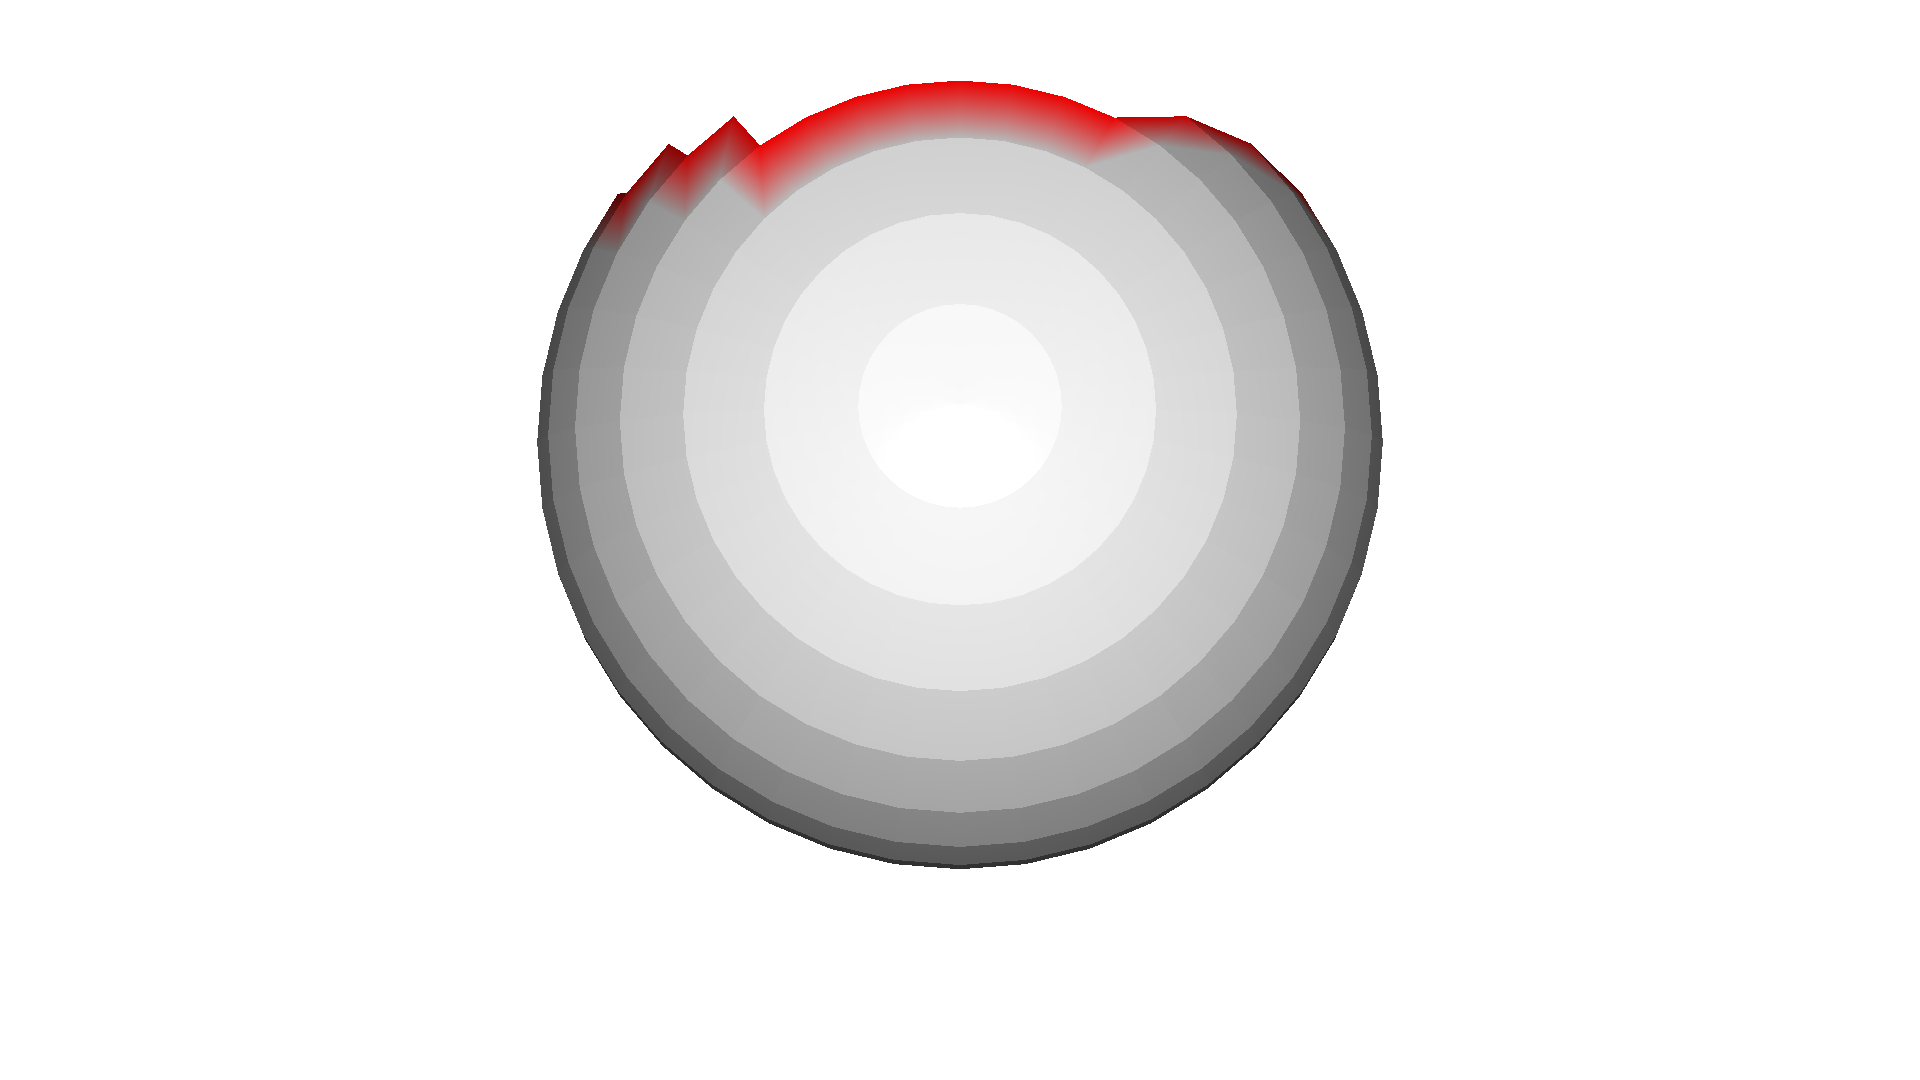

In [3]:
# Colorize boundary vertices to red
vertex_colors = 0.75 * np.ones((len(het_mesh.vertices), 3))
for boundary in het_mesh.get_boundaries():
    for vertex_id in boundary:
        vertex_colors[vertex_id] = [1, 0, 0]
het_mesh.vertex_colors = cv3d.utility.Vector3dVector(vertex_colors)
cv3d.visualization.draw_geometries([het_mesh], mesh_show_back_face=True)

## Colorize the Boundaries of a Mesh

A call to `geometry.TriangleMesh.get_boundaries` returns a vector of boundaries, where each boundary is a vector of vertices. Each vertex color is represented by an RBG array and `Vector3dVector` is used to convert `vertex_colors` of shape (n, 3) to cloudViewer format. Finally, the vertex colors are set on the mesh.